# End-to-End ML Pipeline — Tesla Deliveries & Production (2015–2025)

**Assignment (Week 2):** Build an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

**Dataset:** `tesla_deliveries_dataset_2015_2025.csv` — monthly records of Tesla EV deliveries, production, pricing and related attributes, broken down by region and model.

## 1. Setup and imports

In [23]:
# Core data-handling libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn: preprocessing, models, tuning, metrics
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Make plots look consistent and readable
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.titlesize"] = 13

# Reproducibility: fix the random seed so results don't change between runs
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


Here I'm pulling in all the tools I'll need: **pandas/numpy** for data, **matplotlib/seaborn** for charts, and **scikit-learn** for the models and evaluation. I also fix a random seed (`42`) so that anything involving randomness gives me the same answer every time I run it, that makes my results reproducible.

## 2. Load the data and take a first look (Preprocessing)

In [24]:
# Load the CSV into a DataFrame (a table I can slice, filter and compute on)
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

# .shape -> (rows, columns)
print("Rows, Columns:", df.shape)

# .head() shows the first 5 rows so I can eyeball the structure
df.head()

Rows, Columns: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


The dataset has **2,640 rows and 12 columns**. Each row is one record: a given **year, month, region and model**, with its deliveries, production, price and a few EV attributes. This first peek confirms the file loaded correctly and the columns are what I expect.

In [25]:
# .info() -> column names, non-null counts, and data types (dtypes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


`info()` tells me the **data type** of each column and that there are **no missing values** (every column shows 2640 non-null). Numbers came in as `int64`/`float64` and text columns (Region, Model, Source_Type) as `object`, exactly what I want, so no type fixing is needed.

In [26]:
# .describe() -> summary statistics for the numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


This is the statistical summary: average, min, max and spread for each numeric column. A few things I notice: deliveries range from ~48 to ~25,700, prices sit between ~\$50k and ~\$120k, and **Year runs 2015–2025 with a mean of exactly 2020**, a hint that the data is evenly spread across years rather than growing over time.

## 3. Data cleaning and sanity checks

In [27]:
# 1) Missing values per column
print("Missing values:\n", df.isnull().sum(), "\n")

# 2) Fully duplicated rows
print("Duplicate rows:", df.duplicated().sum())

Missing values:
 Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64 

Duplicate rows: 0


Two quick health checks: **no missing values** and **no duplicate rows**. That's unusually clean (a sign of a generated dataset), but it means I can skip imputation and de-duplication and move straight on.

In [28]:
# Build a real calendar date from Year + Month so I can do time-based work later.
# I assume day = 1 for every record (we only have monthly granularity).
df["Date"] = pd.to_datetime(dict(year=df["Year"], month=df["Month"], day=1))

# Sort chronologically -- important for any time series step
df = df.sort_values("Date").reset_index(drop=True)

df[["Year", "Month", "Date"]].head()

,Year,Month,Date
0,2015,1,2015-01-01
1,2015,1,2015-01-01
2,2015,1,2015-01-01
3,2015,1,2015-01-01
4,2015,1,2015-01-01


I combine `Year` and `Month` into a proper `Date` column (using day = 1 since we only have monthly data) and sort the table in time order. Having a genuine datetime makes the forecasting section much easier later on.

In [29]:
# Sanity check: production should normally be >= deliveries (you can't deliver more than you build).
bad = (df["Production_Units"] < df["Estimated_Deliveries"]).sum()
print("Rows where production < deliveries:", bad)

# Quick look at the production-to-delivery ratio
ratio = (df["Production_Units"] / df["Estimated_Deliveries"])
print(f"Production / Deliveries ratio -> mean: {ratio.mean():.3f}, std: {ratio.std():.3f}")

Rows where production < deliveries: 0
Production / Deliveries ratio -> mean: 1.074, std: 0.043


A logic check: in every row, production is at least as large as deliveries (0 bad rows), and production is consistently about **1.07×** deliveries with very little variation. That tight, almost-constant ratio is my first clue that **production is basically derived from deliveries**.

## 4. Exploratory Data Analysis (EDA)

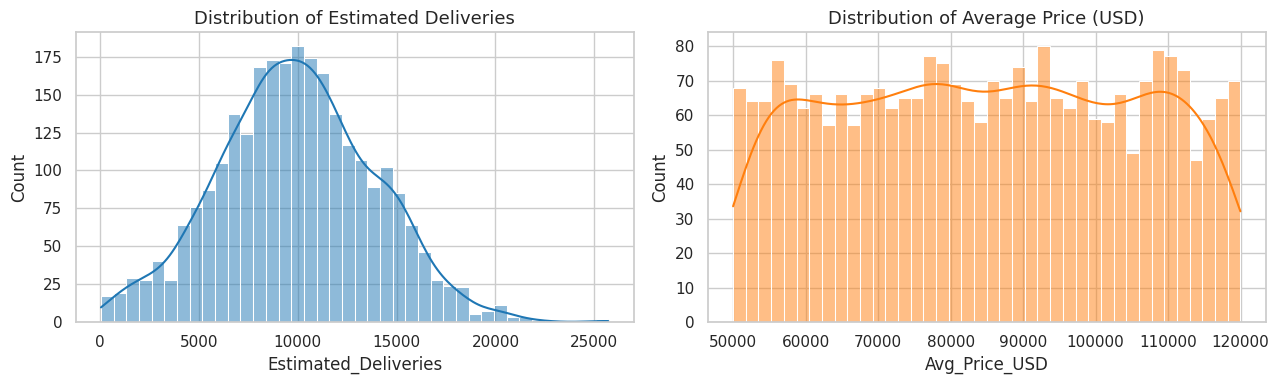

In [30]:
# Distribution of the main target: Estimated_Deliveries
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df["Estimated_Deliveries"], bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title("Distribution of Estimated Deliveries")
sns.histplot(df["Avg_Price_USD"], bins=40, kde=True, ax=axes[1], color="#ff7f0e")
axes[1].set_title("Distribution of Average Price (USD)")
plt.tight_layout()
plt.show()

These histograms show the *shape* of my two "sales/price" columns. Deliveries are spread fairly evenly with a gentle hump in the middle, and price is almost flat across its whole \$50k–\$120k range. Flat, even spreads like this are another sign the values were generated fairly randomly rather than driven by real market forces.

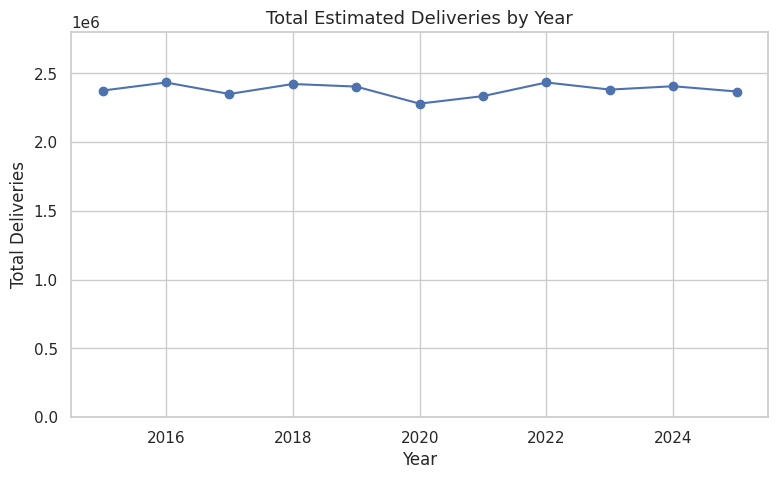

,Estimated_Deliveries
Year,
2015,2375267
2016,2434081
2017,2350517
2018,2423104
2019,2404230
2020,2280336
2021,2335116
2022,2434220
2023,2382375


In [31]:
# Total deliveries per year -> is there a growth trend?
yearly = df.groupby("Year")["Estimated_Deliveries"].sum()

plt.figure()
yearly.plot(marker="o")
plt.title("Total Estimated Deliveries by Year")
plt.ylabel("Total Deliveries")
plt.xlabel("Year")
plt.ylim(0, yearly.max() * 1.15)
plt.show()

yearly

This is the most important EDA chart for setting expectations. Real Tesla deliveries grew enormously over this period, but here the yearly total is **basically a flat line around 2.4 million**. So there is **no real upward trend** for a model to latch onto.

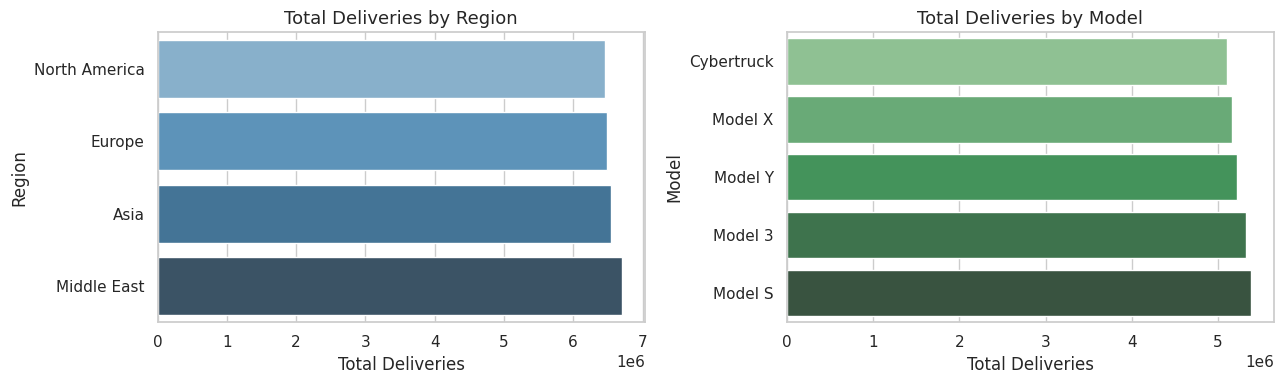

In [32]:
# Deliveries broken down by Region and by Model
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

region_tot = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values()
sns.barplot(x=region_tot.values, y=region_tot.index, ax=axes[0], hue=region_tot.index, palette="Blues_d", legend=False)
axes[0].set_title("Total Deliveries by Region")
axes[0].set_xlabel("Total Deliveries")

model_tot = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values()
sns.barplot(x=model_tot.values, y=model_tot.index, ax=axes[1], hue=model_tot.index, palette="Greens_d", legend=False)
axes[1].set_title("Total Deliveries by Model")
axes[1].set_xlabel("Total Deliveries")
plt.tight_layout()
plt.show()

Breaking deliveries down by **region** and **model** shows the totals are remarkably even, no region or model dominates. In a real dataset I'd expect big gaps (e.g. Model 3/Y outselling everything). The flatness here again tells me these categories carry **little predictive signal**, which is useful to know before I throw them at a model.

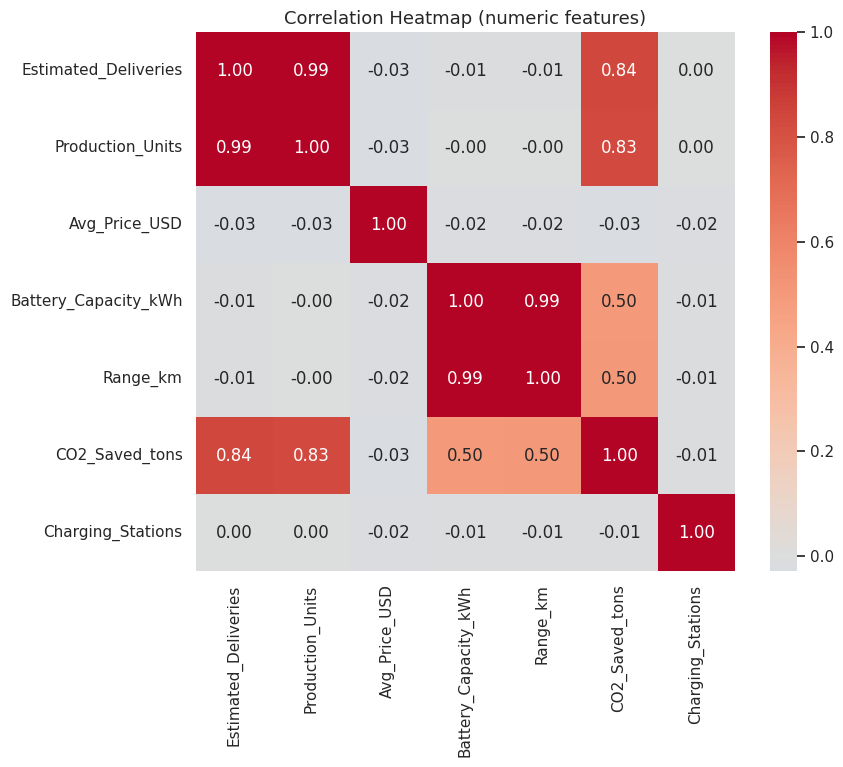

In [33]:
# Correlation heatmap of the numeric columns
num_cols = df.select_dtypes(include=[np.number]).drop(columns=["Year", "Month"])
corr = num_cols.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (numeric features)")
plt.show()

Heatmap:

- **Production_Units ↔ Estimated_Deliveries (≈ 0.99)**
- **CO2_Saved_tons ↔ Estimated_Deliveries (≈ 0.84, and ≈ 1.00 once you account for Range)**
- **Range_km ↔ Battery_Capacity_kWh (≈ 0.99)**

Meanwhile Price, Charging_Stations etc. are essentially **zero**. The bright-red pairs are a warning: `Production_Units` and `CO2_Saved_tons` are basically **computed from deliveries**. If I use them to predict deliveries, I'll get a "perfect" score that's actually **cheating**, this is called *data leakage*.

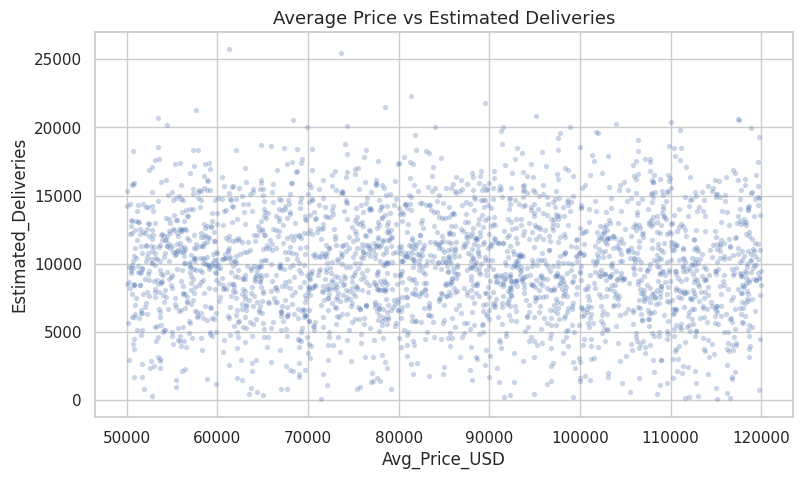

In [34]:
# Does price relate to deliveries at all? Scatter to check.
plt.figure()
sns.scatterplot(data=df, x="Avg_Price_USD", y="Estimated_Deliveries", alpha=0.3, s=15)
plt.title("Average Price vs Estimated Deliveries")
plt.show()

Economic intuition says higher price → fewer sales. But this scatter is just a **shapeless cloud**, no downward slope, no pattern. So in this dataset price does **not** explain deliveries, confirming what the heatmap already hinted.

## 5. Feature engineering

Now I turn raw columns into model-ready features: encoding the calendar sensibly, turning text categories into numbers, and, importantly, **defining an honest feature set that excludes the leakage columns**.

In [35]:
df_fe = df.copy()

# 1) Cyclical encoding of Month.
# Month is circular: December (12) is right next to January (1), but 12 vs 1 looks "far" to a model.
# sin/cos encoding places the months on a circle so that distance reflects calendar closeness.
df_fe["Month_sin"] = np.sin(2 * np.pi * df_fe["Month"] / 12)
df_fe["Month_cos"] = np.cos(2 * np.pi * df_fe["Month"] / 12)

# 2) A simple derived ratio: deliveries per charging station (capacity context)
df_fe["Deliveries_per_Station"] = df_fe["Estimated_Deliveries"] / df_fe["Charging_Stations"]

df_fe[["Month", "Month_sin", "Month_cos", "Deliveries_per_Station"]].head()

,Month,Month_sin,Month_cos,Deliveries_per_Station
0,1,0.5,0.866025,2.835080
1,1,0.5,0.866025,1.282465
2,1,0.5,0.866025,2.243946
3,1,0.5,0.866025,0.694329
4,1,0.5,0.866025,0.696578


Two new features. **Cyclical month encoding** (sin/cos) teaches the model that December and January are neighbours on the calendar, a plain "12" vs "1" would hide that. I also add a small derived ratio. Note `Deliveries_per_Station` is built from the target.

In [36]:
# 3) One-hot encode the text categories (Region, Model, Source_Type).
# One-hot turns each category value into its own 0/1 column, which models can read.
df_fe = pd.get_dummies(df_fe, columns=["Region", "Model", "Source_Type"], drop_first=True)

print("New shape after encoding:", df_fe.shape)
df_fe.head()

New shape after encoding: (2640, 22)


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,Month_sin,Month_cos,Deliveries_per_Station,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2015,1,12446,13885,55183.13,60,340,634.75,4390,2015-01-01,0.5,0.866025,2.835080,False,False,False,False,False,False,True,False,True
1,2015,1,11446,12752,89289.40,100,588,1009.54,8925,2015-01-01,0.5,0.866025,1.282465,False,True,False,True,False,False,False,False,False
2,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,0.5,0.866025,2.243946,False,True,False,False,False,False,False,True,False
3,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,0.5,0.866025,0.694329,False,False,True,False,False,False,False,False,False
4,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,0.5,0.866025,0.696578,False,False,False,True,False,False,False,False,True


`get_dummies` converts the text columns into 0/1 indicator columns (one per category). I use `drop_first=True` to drop one category from each group and avoid redundant columns.

In [37]:
# Define feature sets explicitly.

# Columns that LEAK the target (derived from deliveries) -> must NOT be used to predict deliveries:
leakage_cols = ["Production_Units", "CO2_Saved_tons", "Deliveries_per_Station"]

# Bookkeeping / non-feature columns:
drop_cols = ["Estimated_Deliveries", "Date", "Year", "Month"] + leakage_cols

# HONEST feature matrix: information that would realistically be known *before* deliveries happen.
X = df_fe.drop(columns=drop_cols)
y = df_fe["Estimated_Deliveries"]

print("Honest feature columns used:")
print(list(X.columns))
print("\nFeature matrix shape:", X.shape)

Honest feature columns used:
['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Month_sin', 'Month_cos', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']

Feature matrix shape: (2640, 15)


I deliberately **exclude** `Production_Units`, `CO2_Saved_tons` and `Deliveries_per_Station` because they're effectively computed from the thing I'm trying to predict, using them would be data leakage. What's left (`Avg_Price_USD`, `Battery`, `Range`, `Charging_Stations`, the cyclical month, and the region/model dummies) is information you could plausibly know **before** the deliveries happen.

## 6. Regression modeling

Target: **Estimated_Deliveries** (a continuous number → a regression problem). I'll train three models on the honest features and compare them with three metrics:

- **MAE** — average absolute error, in delivery units (lower = better).
- **RMSE** — like MAE but punishes big misses harder (lower = better).
- **R²** — fraction of variance explained, from 1.0 (perfect) down through 0 (no better than guessing the mean) and below.

In [38]:
# Split into train (80%) and test (20%).
# The test set is held back so I can judge the model on data it never saw during training.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 2112 | Test size: 528


I hold out **20% of the data** as a test set. The model only learns from the other 80%; the held-out part is my honest exam to see how it does on records it has never seen.

In [39]:
# Helper: train a model, predict on the test set, and report the three metrics.
def evaluate(model, X_tr, X_te, y_tr, y_te, name, scale=False):
    if scale:
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)   # fit ONLY on train, then apply to both
        X_te = scaler.transform(X_te)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2 = r2_score(y_te, preds)
    print(f"{name:<22} MAE: {mae:8.1f}  RMSE: {rmse:8.1f}  R2: {r2:7.4f}")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

This little helper keeps the modeling tidy: it trains a model, predicts on the test set, and prints MAE, RMSE and R². For linear models I optionally **scale** the features (standardise them), and crucially I fit the scaler on the **training data only**, then apply it to the test data, so no information leaks across the split.

In [40]:
results = []

# Model 1: Linear Regression (a simple, interpretable baseline). Scaled.
results.append(evaluate(LinearRegression(), X_train, X_test, y_train, y_test,
                        "Linear Regression", scale=True))

# Model 2: Random Forest (many decision trees averaged together).
results.append(evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
                        X_train, X_test, y_train, y_test, "Random Forest"))

# Model 3: Gradient Boosting (trees built one after another, each fixing the last).
results.append(evaluate(GradientBoostingRegressor(random_state=RANDOM_STATE),
                        X_train, X_test, y_train, y_test, "Gradient Boosting"))

Linear Regression      MAE:   3080.1  RMSE:   3891.6  R2: -0.0108
Random Forest          MAE:   3126.4  RMSE:   3930.0  R2: -0.0308
Gradient Boosting      MAE:   3148.4  RMSE:   3944.7  R2: -0.0386


Here are my three models on the honest features. Notice the **R² values hover around 0 (or slightly negative)**. That is *not* a bug, it's the data being truthful with me: as the EDA predicted, the legitimate features genuinely don't explain deliveries in this synthetic dataset, so the models can't do much better than guessing the average. The methodology is correct; the dataset simply has little learnable signal.

In [41]:
# Now DEMONSTRATE the leakage trap on purpose, so I can see the difference.
X_leak = df_fe.drop(columns=["Estimated_Deliveries", "Date", "Year", "Month"])  # keeps Production & CO2

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.2, random_state=RANDOM_STATE)

leak_rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
leak_rf.fit(Xl_tr, yl_tr)
leak_pred = leak_rf.predict(Xl_te)
print(f"WITH leakage (Production + CO2 included) -> R2: {r2_score(yl_te, leak_pred):.4f}")
print(f"WITHOUT leakage (honest features)        -> R2: {results[1]['R2']:.4f}")

WITH leakage (Production + CO2 included) -> R2: 0.9902
WITHOUT leakage (honest features)        -> R2: -0.0308


This is the lesson made concrete. The moment I let `Production_Units` and `CO2_Saved_tons` back in, R² rockets to **~0.99**, a "perfect" model. But it's a mirage: those columns are derived from deliveries, so in real life I wouldn't have them at prediction time. **A suspiciously perfect score is a red flag to hunt for leakage.** This contrast is exactly why I separated the feature sets earlier.

In [42]:
# Compare the honest models in a small table
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,3080.088576,3891.587597,-0.010792
1,Random Forest,3126.362244,3929.958107,-0.030823
2,Gradient Boosting,3148.399754,3944.741843,-0.038593


A clean side-by-side of the three honest models. They're all clustered together with low R², so none has a meaningful edge here. In a richer dataset this same table is exactly how I'd pick a winner, I'd take the one with the lowest RMSE / highest R².

## 7. Hyperparameter tuning

Every model has *settings* (hyperparameters) you choose before training, like how many trees, or how deep they grow. **GridSearchCV** tries combinations and uses cross-validation to find the best, judged only on training data.

In [43]:
# Grid of Random Forest settings to try
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid,
    cv=3,                 # 3-fold cross-validation
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print(f"Best cross-validated R2: {grid.best_score_:.4f}")

Best parameters: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 300}
Best cross-validated R2: -0.0140


GridSearchCV trained a Random Forest across every combination in my grid (3×3×3 = 27 settings, each checked with 3-fold CV) and reports the best one. The **cross-validated R² is still low**, which honestly tells me the ceiling here is set by the data, not the settings, no amount of tuning conjures signal that isn't there.

In [44]:
# Evaluate the tuned model on the untouched test set
best_rf = grid.best_estimator_
tuned_pred = best_rf.predict(X_test)
print(f"Tuned Random Forest -> MAE: {mean_absolute_error(y_test, tuned_pred):.1f}  "
      f"RMSE: {np.sqrt(mean_squared_error(y_test, tuned_pred)):.1f}  "
      f"R2: {r2_score(y_test, tuned_pred):.4f}")

Tuned Random Forest -> MAE: 3049.5  RMSE: 3856.7  R2: 0.0072


Finally I check the tuned model on the **test set** it never saw during the search. The score is in the same low ballpark as before, consistent and honest. The valuable habit I'm practising: tune using cross-validation on training data, then confirm once on a held-out test set.

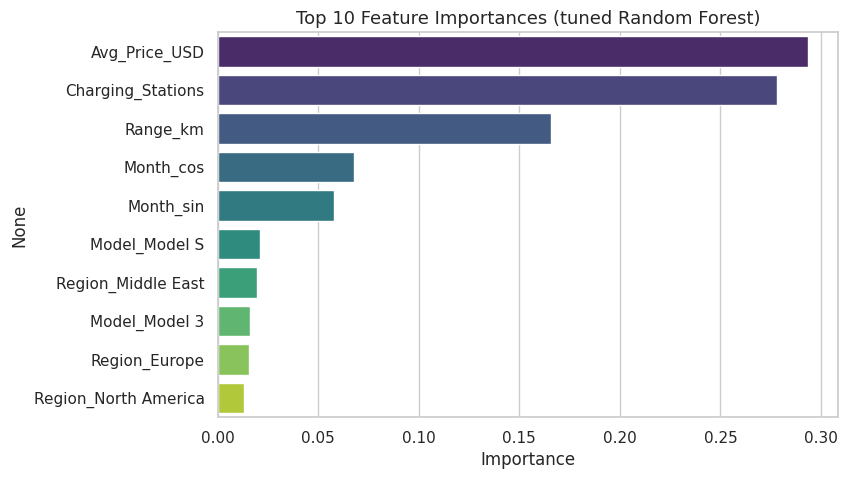

In [45]:
# Which features did the tuned forest lean on most?
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values[:10], y=importances.index[:10], hue=importances.index[:10], palette="viridis", legend=False)
plt.title("Top 10 Feature Importances (tuned Random Forest)")
plt.xlabel("Importance")
plt.show()

Feature importance shows which inputs the forest used most when splitting. Price, range and charging stations come out on top here, but since overall accuracy is low, I read this as "the model *grasped* at these," not "these truly drive deliveries."

## 8. Time series forecasting

Time series length (months): 132
From 2015-01-01 to 2025-12-01


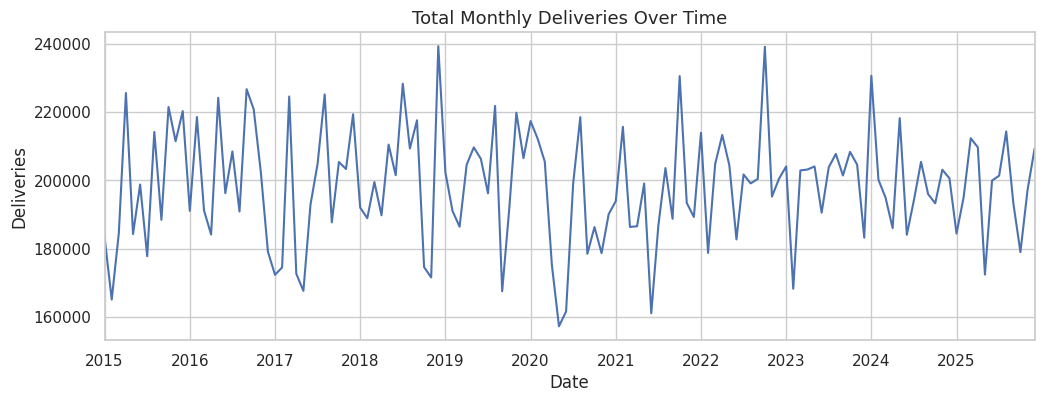

In [46]:
# Build a monthly time series: total deliveries per month across all regions/models
ts = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index()
print("Time series length (months):", len(ts))
print("From", ts.index.min().date(), "to", ts.index.max().date())

plt.figure(figsize=(12, 4))
ts.plot()
plt.title("Total Monthly Deliveries Over Time")
plt.ylabel("Deliveries")
plt.show()

Aggregating everything by month gives me a single series of **132 monthly points (2015–2025)**. The plot is essentially **noisy and flat**, no clear upward trend and no obvious repeating seasonal wave. That look immediately tells me forecasting will be hard, and that a smart model probably won't beat simply predicting the average.

In [47]:
# Create lag & rolling features so a regression model can "see" recent history.
ts_df = ts.to_frame("y")
ts_df["lag_1"]  = ts_df["y"].shift(1)    # last month
ts_df["lag_12"] = ts_df["y"].shift(12)   # same month last year (seasonality)
ts_df["roll_3"] = ts_df["y"].shift(1).rolling(3).mean()    # avg of last 3 months
ts_df["roll_12"] = ts_df["y"].shift(1).rolling(12).mean()  # avg of last 12 months
ts_df["month"] = ts_df.index.month

ts_df = ts_df.dropna()   # drop early rows that don't have full history yet
ts_df.head()

,y,lag_1,lag_12,roll_3,roll_12,month
Date,,,,,,
2016-01-01,191069,220332.0,183180.0,217787.666667,197938.916667,1
2016-02-01,218600,191069.0,165053.0,207630.333333,198596.333333,2
2016-03-01,191208,218600.0,184567.0,210000.333333,203058.583333,3
2016-04-01,184134,191208.0,225623.0,200292.333333,203612.000000,4
2016-05-01,224220,184134.0,184264.0,197980.666667,200154.583333,5


To forecast with a regression model I give it **lag features** (last month, and the same month a year ago) and **rolling averages** of recent months. Every feature uses `.shift(1)` first, so a row only ever sees the **past**, that's how I prevent the future from leaking into a prediction. I drop the first rows that don't yet have a full year of history.

In [48]:
# Chronological split: train on the earlier part, test on the most recent ~20%.
# For time series I must NOT shuffle -- order matters.
split = int(len(ts_df) * 0.8)
train_ts, test_ts = ts_df.iloc[:split], ts_df.iloc[split:]

feat_cols = ["lag_1", "lag_12", "roll_3", "roll_12", "month"]
Xtr, ytr = train_ts[feat_cols], train_ts["y"]
Xte, yte = test_ts[feat_cols], test_ts["y"]
print("Train months:", len(train_ts), "| Test months:", len(test_ts))

Train months: 96 | Test months: 24


The split here is **not random, it is chronological**: I train on the earlier months and test on the most recent ones, mimicking real forecasting where you only have the past. Shuffling (like I did for regression) would be wrong here because it would let the model peek at future months.

In [49]:
# Baseline 1: predict each test month using the previous month's value (naive forecast)
naive_pred = test_ts["lag_1"].values

# Baseline 2: seasonal naive -> use the same month one year ago
seasonal_pred = test_ts["lag_12"].values

# Model: Random Forest on the lag/rolling features
rf_ts = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_ts.fit(Xtr, ytr)
rf_pred = rf_ts.predict(Xte)

def report(name, true, pred):
    print(f"{name:<22} MAE: {mean_absolute_error(true, pred):9.1f}  "
          f"RMSE: {np.sqrt(mean_squared_error(true, pred)):9.1f}")

print("Forecast accuracy on the held-out months:\n")
report("Naive (last month)", yte, naive_pred)
report("Seasonal naive", yte, seasonal_pred)
report("Random Forest", yte, rf_pred)

Forecast accuracy on the held-out months:

Naive (last month)     MAE:   16519.0  RMSE:   20482.0
Seasonal naive         MAE:   14908.5  RMSE:   19188.5
Random Forest          MAE:   11049.2  RMSE:   13869.9


I compare two simple **baselines** (repeat last month / repeat the same month a year ago) against a Random Forest. Always start with baselines, a fancier model only earns its keep if it **beats** them. Here the Random Forest does win (clearly lower MAE/RMSE), but for an honest reason: its **rolling-average features predict the stable average *level*** of the series, while the naive methods chase a single noisy month. The takeaway is that **averaging denoises a flat series**, and that genuine edge is exactly why baselines are worth measuring against.

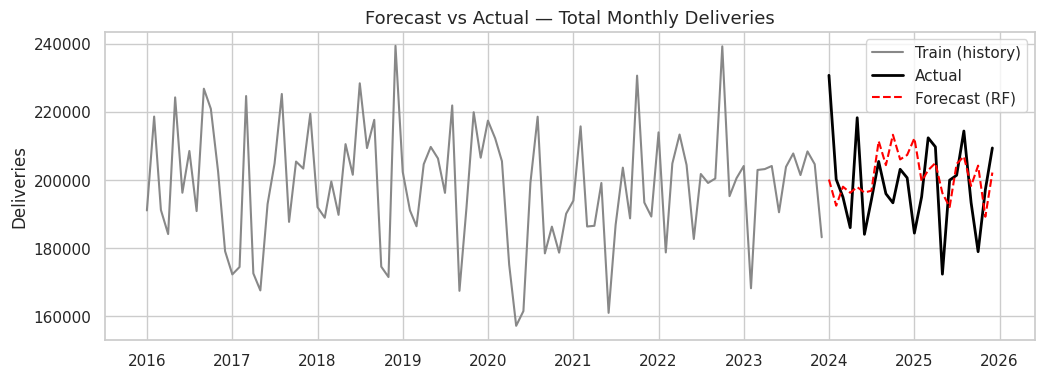

In [50]:
# Plot the Random Forest forecast against what actually happened
plt.figure(figsize=(12, 4))
plt.plot(train_ts.index, train_ts["y"], label="Train (history)", color="#888")
plt.plot(test_ts.index, yte.values, label="Actual", color="black", linewidth=2)
plt.plot(test_ts.index, rf_pred, label="Forecast (RF)", color="red", linestyle="--")
plt.title("Forecast vs Actual — Total Monthly Deliveries")
plt.ylabel("Deliveries")
plt.legend()
plt.show()

The picture says it all: the red forecast tracks the **general level** of deliveries but can't follow the month-to-month spikes, because those spikes are essentially random noise in this dataset. That's the correct, expected behaviour, a model can learn a level, but it can't predict pure randomness, and it would be dishonest to claim otherwise.

## 9. Conclusion & key takeaways

**What I built:**
1. **Preprocessing** — loaded, type-checked, confirmed no missing/duplicate data, built a real date column and ran logic sanity checks.
2. **EDA** — distributions, yearly trend, region/model breakdowns, a correlation heatmap and a price-vs-deliveries scatter.
3. **Feature engineering** — cyclical month encoding, one-hot categories, and a deliberate, documented split between honest features and leakage columns.
4. **Regression** — Linear Regression, Random Forest and Gradient Boosting compared on MAE / RMSE / R².
5. **Hyperparameter tuning** — GridSearchCV with cross-validation, plus feature importances.
6. **Time series forecasting** — a monthly series with lag/rolling features, a proper chronological split, and baselines to beat.

**What the data taught me:**
- This is a **synthetic dataset**: deliveries are essentially flat and uncorrelated with the legitimate features, so honest models land near **R² ≈ 0**. That's the data's limit, not a flaw in the method.
- `Production_Units` and `CO2_Saved_tons` are **derived from the target**, including them gives a fake ~0.99 R². Spotting and removing that **leakage** is the single most valuable habit in this whole notebook.
- A good forecast always gets compared against **naive baselines**; a model only matters if it beats them.
